# Notebook 07 — Train GNN Baseline

k-NN Graph Convolutional Network + weight-shared GRU for multi-site AirNow NO₂ forecasting.

**Input :** `(batch, seq_len, n_sites)` — normalised look-back window  
**Output :** `(batch, pred_len, n_sites)` — forecast horizon  
**Architecture :** `GCNLayer × n_layers [at each time step] → weight-shared GRU per site → Linear head`  
**Graph :** k-nearest-neighbours by Haversine distance, symmetrised, D⁻½AD⁻½ normalised


In [1]:
import json, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

from data.load_airnow import load_sequences, site_meta, DATA_DIR, TRAIN_END, FULL_TRAIN_END
from models.gnn_no2 import NO2GNN, build_knn_adj
from models.transformer_no2 import _make_loader, evaluate

OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEQ_LEN    = 24      # look-back window (hours)
PRED_LEN   = 6       # forecast horizon (hours)
D_MODEL    = 64      # GCN output / GRU hidden dimension
N_LAYERS   = 2       # GCN layers per time step
K_NN       = 5       # k-nearest neighbours for graph
DROPOUT    = 0.1
EPOCHS     = 50
BATCH_SIZE = 64
LR         = 1e-3
PATIENCE   = 8

# ── Split boundaries (12-month train / 3-month test) ──────────────────────────
# Train   : 2023-07-01 → 2024-05-31  (TRAIN_END)
# Val     : 2024-06-01 → 2024-06-30  (FULL_TRAIN_END)   ─╮  12-month
# Test    : 2024-07-01 → 2024-09-30               ─╯  held-out

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device     : {DEVICE}")
print(f"Config     : seq={SEQ_LEN}h  pred={PRED_LEN}h  d={D_MODEL}  layers={N_LAYERS}  k={K_NN}")
print(f"Train end  : {TRAIN_END.date()}   Val end : {FULL_TRAIN_END.date()}")


Device     : cpu
Config     : seq=24h  pred=6h  d=64  layers=2  k=5
Train end  : 2024-05-31   Val end : 2024-06-30


/mnt/data3/isybelle1118/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1 · Load & Split Data


In [2]:
print("Loading sequences …")
X, y, timestamps, site_codes = load_sequences(
    DATA_DIR, seq_len=SEQ_LEN, pred_len=PRED_LEN,
    stride=1, fill_nan=0.0, normalize=True,
    norm_end=str(TRAIN_END),            # normalise on training data only
)
N_SITES = X.shape[2]

ts        = pd.to_datetime(timestamps)
idx_train = ts <= TRAIN_END
idx_val   = (ts > TRAIN_END) & (ts <= FULL_TRAIN_END)
idx_test  = ts > FULL_TRAIN_END

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

print(f"  Sites     : {N_SITES}")
print(f"  Train     : {idx_train.sum():,} windows  ({ts[idx_train][0].date()} → {ts[idx_train][-1].date()})")
print(f"  Val       : {idx_val.sum():,} windows  ({ts[idx_val][0].date()} → {ts[idx_val][-1].date()})")
print(f"  Test      : {idx_test.sum():,} windows  ({ts[idx_test][0].date()} → {ts[idx_test][-1].date()})")


Loading sequences …


  Sites     : 197
  Train     : 8,064 windows  (2023-07-01 → 2024-05-31)
  Val       : 720 windows  (2024-06-01 → 2024-06-30)
  Test      : 2,179 windows  (2024-07-01 → 2024-09-29)


## 2 · Build k-NN Graph

Derive the spatial graph from station lat/lon coordinates.  
Each site is connected to its **k nearest neighbours** by great-circle distance.  
The adjacency is symmetrised, self-loops are added, then normalised: D⁻½ A D⁻½.


Graph summary:
  Nodes        : 182
  Non-zero entries : 1,398
  Edges per site  : min=6  mean=7.7  max=12


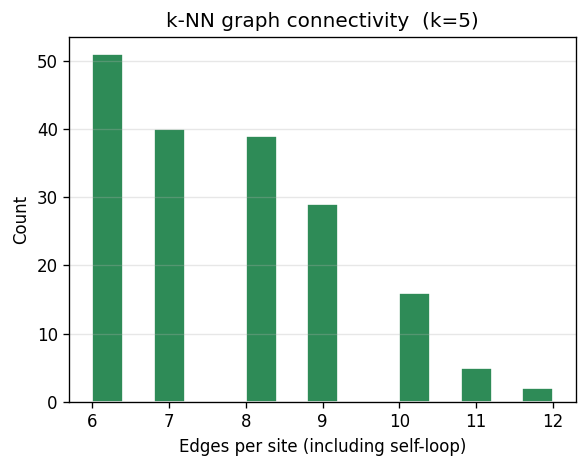

In [3]:
meta = site_meta(DATA_DIR)
adj  = build_knn_adj(meta["lat"].values, meta["lon"].values, k=K_NN)

# Visualise sparsity
edges_per_site = (adj > 0).sum(dim=1).float()
print(f"Graph summary:")
print(f"  Nodes        : {adj.shape[0]}")
print(f"  Non-zero entries : {(adj > 0).sum().item():,}")
print(f"  Edges per site  : min={int(edges_per_site.min())}  "
      f"mean={edges_per_site.mean():.1f}  max={int(edges_per_site.max())}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(edges_per_site.numpy(), bins=15, color="seagreen", edgecolor="white")
ax.set_xlabel("Edges per site (including self-loop)")
ax.set_ylabel("Count")
ax.set_title(f"k-NN graph connectivity  (k={K_NN})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 3 · Build Model


In [4]:
model = NO2GNN(
    n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN,
    d_model=D_MODEL, n_layers=N_LAYERS, k_nn=K_NN,
    adj=adj, dropout=DROPOUT,
)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParameters : {n_params:,}")
print(f"Adj buffer : {tuple(model.adj.shape)}  (saved with checkpoint)")

CKPT_NAME = f"gnn_s{SEQ_LEN}_p{PRED_LEN}_d{D_MODEL}.pt"
CKPT_PATH = OUTPUTS / CKPT_NAME
print(f"Checkpoint : {CKPT_PATH}")


NO2GNN(
  (gcn_layers): ModuleList(
    (0): GCNLayer(
      (weight): Linear(in_features=1, out_features=64, bias=True)
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (1): GCNLayer(
      (weight): Linear(in_features=64, out_features=64, bias=True)
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (gcn_skip): ModuleList(
    (0): Linear(in_features=1, out_features=64, bias=False)
    (1): Linear(in_features=64, out_features=64, bias=False)
  )
  (gru): GRU(64, 64, batch_first=True)
  (drop): Dropout(p=0.1, inplace=False)
  (output_proj): Linear(in_features=64, out_features=6, bias=True)
)

Parameters : 34,054
Adj buffer : (182, 182)  (saved with checkpoint)
Checkpoint : /mnt/data3/isybelle1118/NO2 Forecasting/outputs/gnn_s24_p6_d64.pt


## 4 · Train


In [5]:
model  = model.to(DEVICE)
opt    = torch.optim.Adam(model.parameters(), lr=LR)
sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
crit   = nn.MSELoss()

train_loader = _make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = _make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)

best_val, no_improve, history = float("inf"), 0, []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        running += loss.item() * len(xb)
    train_mse = running / len(X_train)

    val_mse, val_mae = evaluate(model, X_val, y_val, device=DEVICE)
    sched.step(val_mse)

    history.append({"epoch": epoch, "train_mse": train_mse,
                    "val_mse": val_mse, "val_mae": val_mae})

    if val_mse < best_val:
        best_val = val_mse
        no_improve = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stop at epoch {epoch}.")
            break

    if epoch % 5 == 0 or epoch == 1:
        elapsed = (time.time() - t0) / 60
        print(f"Ep {epoch:3d} | train MSE {train_mse:.4f} | "
              f"val MSE {val_mse:.4f}  MAE {val_mae:.4f} | "
              f"{elapsed:.1f} min  [best {best_val:.4f}]")

print(f"\nBest val MSE : {best_val:.4f}  — checkpoint → {CKPT_PATH.name}")
print(f"Adj buffer saved with model state dict.")


RuntimeError: einsum(): subscript j has size 197 for operand 1 which does not broadcast with previously seen size 182

## 5 · Evaluate on Test Set


In [6]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
test_mse, test_mae = evaluate(model, X_test, y_test, device=DEVICE)
print(f"{'='*45}")
print(f"  TEST  MSE = {test_mse:.4f}   MAE = {test_mae:.4f}")
print(f"{'='*45}")

meta_dict = {
    "model": "gnn", "n_sites": N_SITES,
    "seq_len": SEQ_LEN, "pred_len": PRED_LEN,
    "d_model": D_MODEL, "n_layers": N_LAYERS, "k_nn": K_NN,
    "n_params": n_params,
    "test_mse": test_mse, "test_mae": test_mae,
    "history": history,
}
hist_path = OUTPUTS / CKPT_NAME.replace(".pt", "_history.json")
hist_path.write_text(json.dumps(meta_dict, indent=2))
print(f"History saved → {hist_path.name}")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data3/isybelle1118/NO2 Forecasting/outputs/gnn_s24_p6_d64.pt'

## 6 · Plots


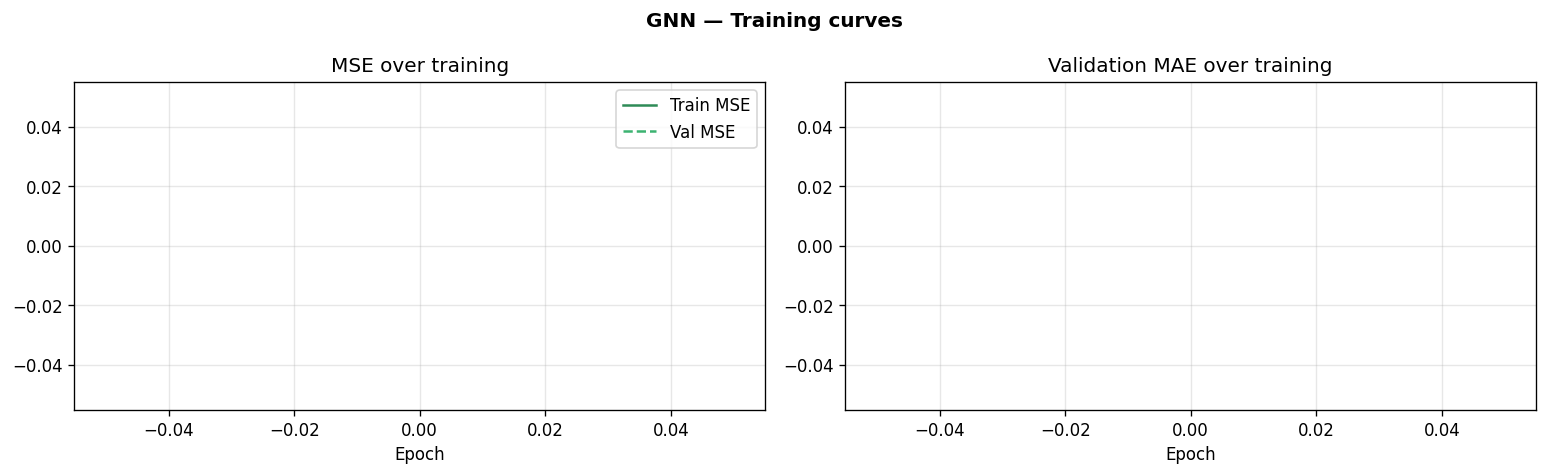

RuntimeError: einsum(): subscript j has size 197 for operand 1 which does not broadcast with previously seen size 182

In [7]:
epochs_    = [h["epoch"]     for h in history]
train_mse_ = [h["train_mse"] for h in history]
val_mse_   = [h["val_mse"]   for h in history]
val_mae_   = [h["val_mae"]   for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs_, train_mse_, color="seagreen", label="Train MSE")
axes[0].plot(epochs_, val_mse_,   color="mediumseagreen", label="Val MSE", ls="--")
axes[0].set_title("MSE over training"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_, val_mae_, color="seagreen")
axes[1].set_title("Validation MAE over training"); axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)

fig.suptitle("GNN — Training curves", fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUTS / "gnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Scatter ────────────────────────────────────────────────────────────────────
model.eval()
preds_list = []
with torch.no_grad():
    for xb, _ in _make_loader(X_test, y_test, 512, shuffle=False):
        preds_list.append(model(xb.to(DEVICE)).cpu().numpy())
preds  = np.concatenate(preds_list)
flat_y = y_test.ravel()
flat_p = preds.ravel()
idx    = np.random.choice(len(flat_y), min(8000, len(flat_y)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(flat_y[idx], flat_p[idx], alpha=0.15, s=5, color="seagreen")
lim = max(flat_y[idx].max(), flat_p[idx].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.9, label="perfect")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Actual NO₂ (normalised)")
ax.set_ylabel("Predicted NO₂ (normalised)")
ax.set_title(f"GNN — Predicted vs Actual (test)\nMSE={test_mse:.4f}  MAE={test_mae:.4f}",
             fontweight="bold")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUTS / "gnn_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
